In [1]:
from utils.dataset import GLORYSDS
from utils.config import DATA_DIR

ds_name = "cmems_mod_glo_phy_my_0.083deg_P1D-m_multi-vars_156.00W-121.42W_41.83N-63.08N_0.49m_2021-06-25-2021-06-30.nc"
ds = GLORYSDS(DATA_DIR/ds_name, days = False, normalize=True)

In [2]:
retrieved_full_annot_oneday = ds.annotations_map[0]
regions = ds.regions
region_size = ds.region_size
grid_size = ds.grid_size
len(regions)

46

In [3]:
one_day_feature_map = ds.feature_map[0]
one_day_feature_map.shape
for channel in one_day_feature_map:
    print(channel)

[[ 1.06653037e+00  1.06653037e+00  1.06653037e+00 ... -3.27670000e+04
  -3.27670000e+04 -3.27670000e+04]
 [ 1.06653037e+00  1.06653037e+00  1.06653037e+00 ... -3.27670000e+04
  -3.27670000e+04 -3.27670000e+04]
 [ 1.06653037e+00  1.06653037e+00  1.06579792e+00 ... -3.27670000e+04
  -3.27670000e+04 -3.27670000e+04]
 ...
 [-3.27670000e+04 -3.27670000e+04 -3.27670000e+04 ... -3.27670000e+04
  -3.27670000e+04 -3.27670000e+04]
 [-3.27670000e+04 -3.27670000e+04 -3.27670000e+04 ... -3.27670000e+04
  -3.27670000e+04 -3.27670000e+04]
 [-3.27670000e+04 -3.27670000e+04 -3.27670000e+04 ... -3.27670000e+04
  -3.27670000e+04 -3.27670000e+04]]
[[    33.65428629     33.60393075     33.55967891 ... -32767.
  -32767.         -32767.        ]
 [    33.66954555     33.64055296     33.61156038 ... -32767.
  -32767.         -32767.        ]
 [    33.65581222     33.64665667     33.63444926 ... -32767.
  -32767.         -32767.        ]
 ...
 [-32767.         -32767.         -32767.         ... -32767.
  -327

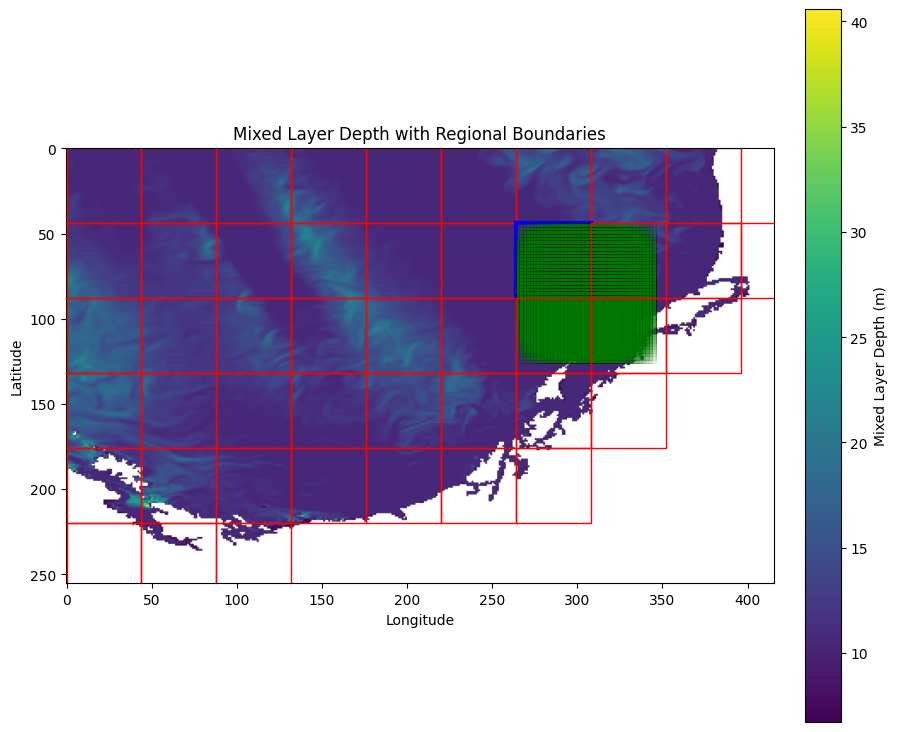

In [4]:
import numpy as np

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(retrieved_full_annot_oneday, cmap='viridis', )
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Mixed Layer Depth (m)')

for (y, x) in regions:
    if (y, x) == list(ds.indices_regionified.keys())[15]:
        rect = plt.Rectangle((x, y), region_size, region_size, 
                         linewidth=3, edgecolor='blue', facecolor='none', alpha=1.0)
        ax.add_patch(rect)
        for (grid_y, grid_x) in ds.indices_regionified[(y, x)]:
            rect = plt.Rectangle((grid_x, grid_y), grid_size, grid_size, 
                         linewidth=0.5, edgecolor='black', facecolor='green', alpha=0.1)
            ax.add_patch(rect)

    else:
        # rect = plt.Rectangle((x - 0.5, y - 0.5), region_size, region_size, 
        #                  linewidth=1, edgecolor='red', facecolor='none')
        rect = plt.Rectangle((x, y), region_size, region_size, 
                         linewidth=1, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

ax.set_title("Mixed Layer Depth with Regional Boundaries")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()